# Technique Comparison 


This notebook aims to compare and show the differences between layer strategies (last4 concat or penultimate) or antropy correction (raw vs corrected)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

In [3]:
# --- CONFIGURACIÓN DE ESTILO ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
colors = sns.color_palette("deep")

# Ajusta la ruta a donde tengas tu archivo parquet
file_path = '../data/phase3_results.parquet' 

try:
    # Usamos read_parquet en lugar de read_csv
    df = pd.read_parquet(file_path)
    print(f"✅ Archivo Parquet cargado: {len(df)} registros.")
except FileNotFoundError:
    print("❌ ERROR: No encuentro el archivo. Verifica la ruta o el nombre.")

# Aseguramos que la fecha esté en formato correcto (Parquet suele guardarlo bien, pero por seguridad)
if 'window_start_month' in df.columns:
    df['date'] = pd.to_datetime(df['window_start_month'])
    df = df.sort_values('date')

# --- 2. CONFIGURACIÓN DE LA COMPARATIVA ---
# Vamos a comparar usando el modelo DAPT (el adaptado a pandemia)
model_type = 'dapt' 

print(f"Comparando métricas para el modelo: {model_type.upper()}")
print("-" * 60)

✅ Archivo Parquet cargado: 11 registros.
Comparando métricas para el modelo: DAPT
------------------------------------------------------------



📈 GENERATING BLOCK A: Layer Comparison...


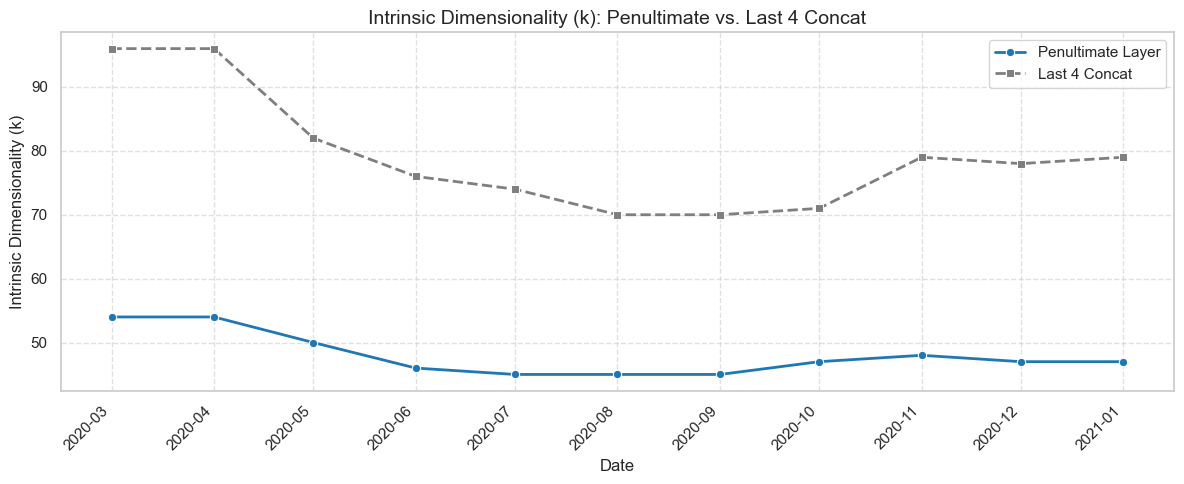

In [8]:
# ==============================================================================
# BLOCK A: LAYER STRATEGY COMPARISON (Penultimate vs Last 4 Concat)
# ==============================================================================

print("\n📈 GENERATING BLOCK A: Layer Comparison...")

plt.figure(figsize=(12, 5))

# 1. Plotting Penultimate Layer
sns.lineplot(data=df, x='date', y=f'k_{model_type}_penultimate', 
             label='Penultimate Layer', marker='o', linewidth=2, color='tab:blue')

# 2. Plotting Last 4 Concat
sns.lineplot(data=df, x='date', y=f'k_{model_type}_last4_concat', 
             label='Last 4 Concat', marker='s', linestyle='--', linewidth=2, color='tab:gray')

# --- English Translations and Styling ---
plt.title('Intrinsic Dimensionality (k): Penultimate vs. Last 4 Concat', fontsize=14)
plt.ylabel('Intrinsic Dimensionality (k)', fontsize=12)
plt.xlabel('Date', fontsize=12)

# --- Date Legibility Fix (Rotation) ---
plt.xticks(rotation=45, ha='right')

plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save or Show
# plt.savefig('Figure_6_Intrinsic_Dimensionality.png', dpi=300)
plt.show()

La línea gris (Last4Concat) se mantiene muy alta (media $k \approx 79$), mientras que la azul (Penultimate) es significativamente más baja (media $k \approx 48$).

La última capa del modelo, al estar concatenada, retiene una enorme cantidad de información superficial y sintáctica (ruido), lo que infla la dimensionalidad. La capa penúltima actúa como un filtro de abstracción, comprimiendo el significado en menos dimensiones.

Penultimate ofrece una representación más "limpia" y semánticamente enfocada del concepto.


📈 GENERATING BLOCK A.2: Semantic Drift Comparison...


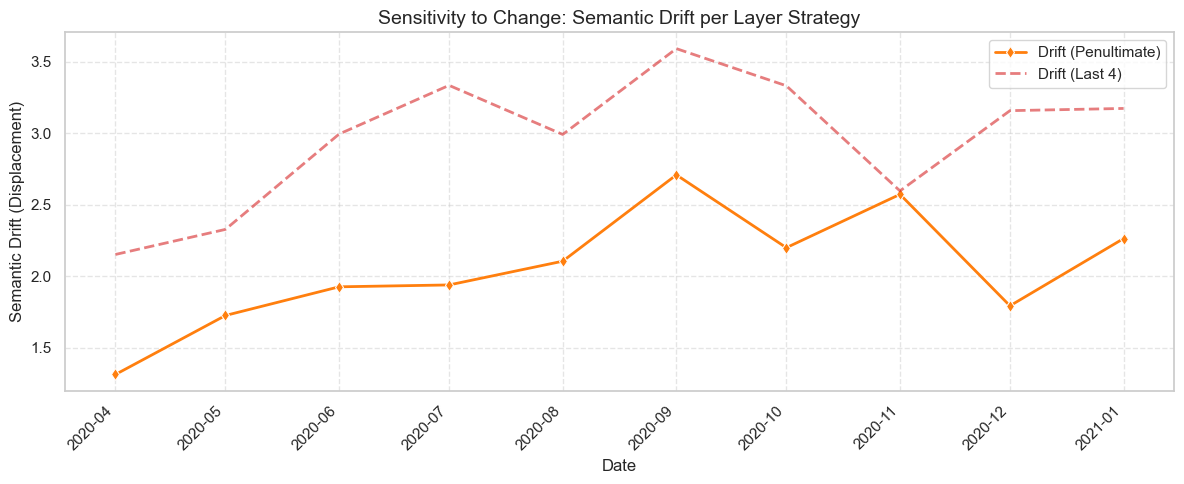

In [13]:
# ==============================================================================
# BLOCK A.2: TEMPORAL STABILITY (Semantic Drift)
# Goal: Measure the "velocity" of conceptual change between months.
# ==============================================================================

print("\n📈 GENERATING BLOCK A.2: Semantic Drift Comparison...")

plt.figure(figsize=(12, 5))

# 1. Plotting Penultimate Layer Drift
sns.lineplot(data=df, x='date', y=f'drift_{model_type}_penultimate', 
             label='Drift (Penultimate)', color='tab:orange', marker='d', linewidth=2)

# 2. Plotting Last 4 Concat Drift
sns.lineplot(data=df, x='date', y=f'drift_{model_type}_last4_concat', 
             label='Drift (Last 4)', color='tab:red', linestyle='--', alpha=0.6, linewidth=2)

# --- English Translations and Styling ---
plt.title('Sensitivity to Change: Semantic Drift per Layer Strategy', fontsize=14)
plt.ylabel('Semantic Drift (Displacement)', fontsize=12)
plt.xlabel('Date', fontsize=12)

# --- Date Legibility ---
plt.xticks(rotation=45, ha='right')

plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save for thesis
# plt.savefig('Figure_X_Semantic_Drift_Comparison.png', dpi=300)
plt.show()

The red line (Last4) has much more aggressive peaks y una media de desplazamiento mayor (2.96) que la naranja (Penultimate, 2.05).

La capa Last4 es "nerviosa"; reacciona excesivamente a cambios menores en el fraseo de las noticias mes a mes. La capa Penultimate muestra una evolución más suave.

La estabilidad de Penultimate sugiere que los cambios que detecta son estructurales (profundos), no meramente variaciones de estilo.

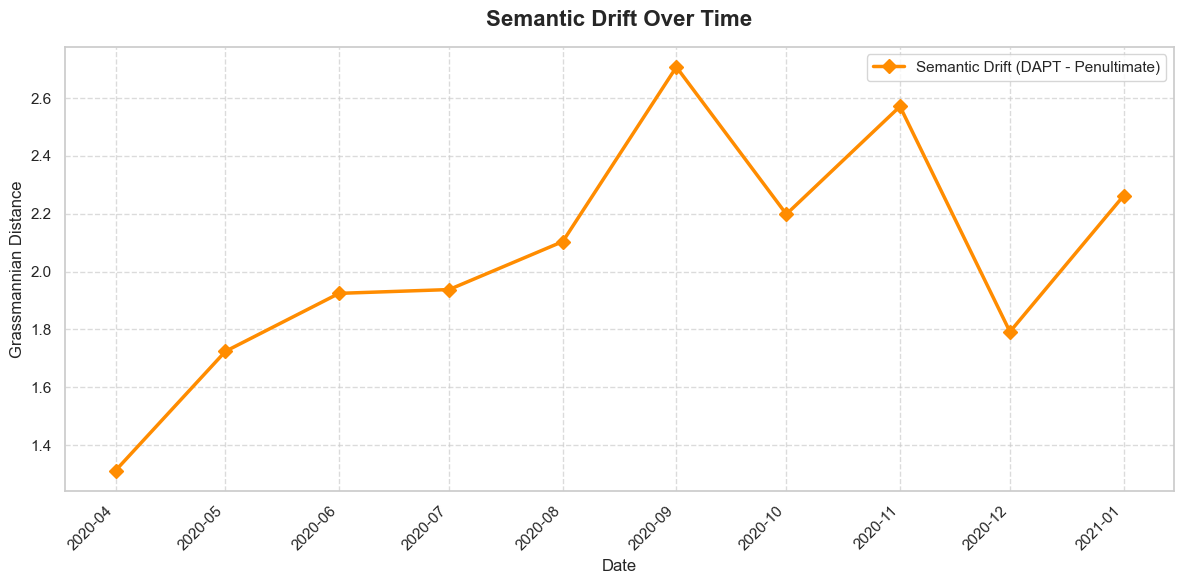

------------------------------------------------------------


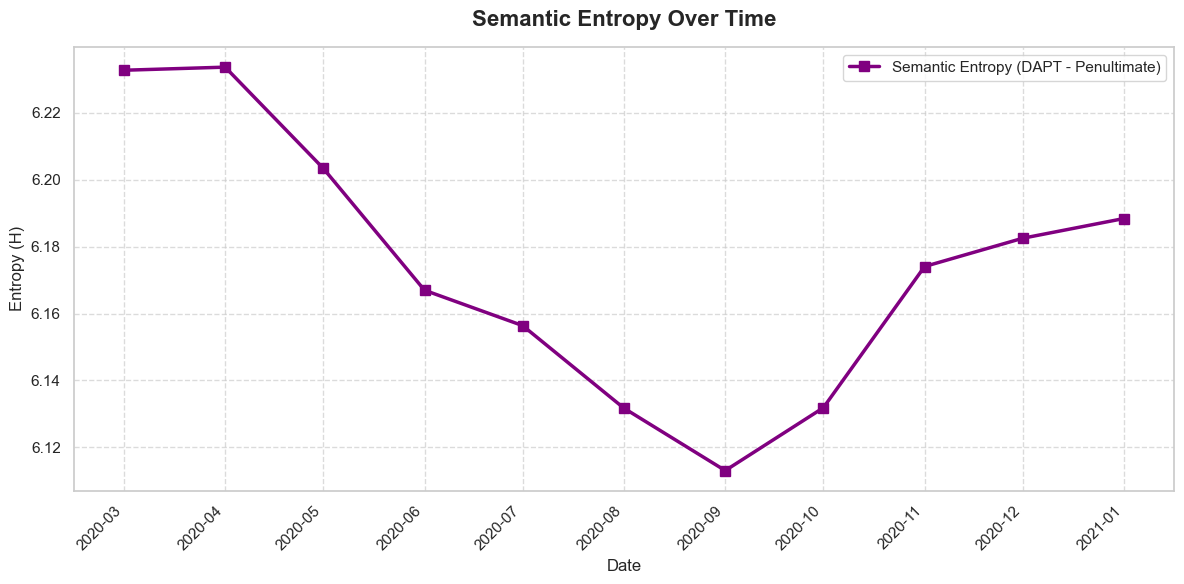

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure style (por si no lo has corrido en esta celda)
sns.set_theme(style="whitegrid")

# (Opcional) Asegurarnos de que 'date' es tipo datetime para que el eje X se formatee bien
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])

# =========================================================
# 1. PLOT: SEMANTIC DRIFT (DAPT - Penultimate)
# =========================================================
plt.figure(figsize=(12, 6))

# Dibujar la línea de Drift
plt.plot(df['date'], df['drift_dapt_penultimate'], 
         marker='D', color='darkorange', linewidth=2.5, markersize=7, 
         label='Semantic Drift (DAPT - Penultimate)')

# Formato del gráfico
plt.title('Semantic Drift Over Time', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Grassmannian Distance', fontsize=12)

# Rotar las fechas para que no se pisen
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best', fontsize=11)
plt.tight_layout()

# Mostrar y opcionalmente guardar
# plt.savefig('semantic_drift.png', dpi=300, bbox_inches='tight')
plt.show()

print("-" * 60)

# =========================================================
# 2. PLOT: SEMANTIC ENTROPY (DAPT - Penultimate)
# =========================================================
plt.figure(figsize=(12, 6))

# Dibujar la línea de Entropía
plt.plot(df['date'], df['entropy_dapt_penultimate'], 
         marker='s', color='purple', linewidth=2.5, markersize=7, 
         label='Semantic Entropy (DAPT - Penultimate)')

# Formato del gráfico
plt.title('Semantic Entropy Over Time', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Entropy (H)', fontsize=12)

# Rotar las fechas
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best', fontsize=11)
plt.tight_layout()

# Mostrar y opcionalmente guardar
# plt.savefig('semantic_entropy.png', dpi=300, bbox_inches='tight')
plt.show()


📈 GENERANDO BLOQUE B: Raw vs Corrected...


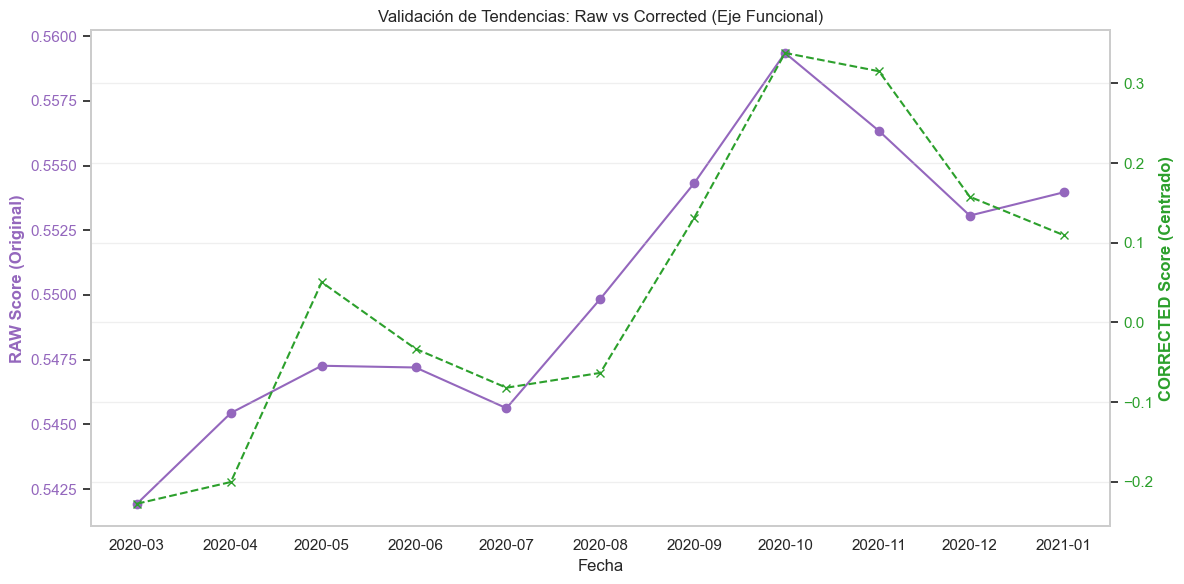

In [28]:
# ==============================================================================
# BLOQUE B: CORRECCIÓN DE ANISOTROPÍA (Raw vs Corrected)
# Objetivo: Demostrar que 'Corrected' no rompe los datos, solo los centra.
# ==============================================================================

print("\n📈 GENERANDO BLOQUE B: Raw vs Corrected...")

# Elegimos un eje para la prueba (ej. Functional)
axis = 'funcional'
layer = 'penultimate'

# Construimos los nombres exactos de tus columnas
col_raw = f'centroid_proj_{axis}_{model_type}_{layer}_raw'
col_corr = f'centroid_proj_{axis}_{model_type}_{layer}_corrected'

# B.1. Tendencia Temporal (Doble Eje Y)
fig, ax1 = plt.subplots(figsize=(12, 6))

color_raw = 'tab:purple'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('RAW Score (Original)', color=color_raw, fontweight='bold')
ax1.plot(df['date'], df[col_raw], color=color_raw, label='RAW', marker='o')
ax1.tick_params(axis='y', labelcolor=color_raw)
ax1.grid(False) # Quitamos grid del eje 1 para no ensuciar

ax2 = ax1.twinx()  # Eje secundario
color_corr = 'tab:green'
ax2.set_ylabel('CORRECTED Score (Centrado)', color=color_corr, fontweight='bold')
ax2.plot(df['date'], df[col_corr], color=color_corr, label='CORRECTED', marker='x', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color_corr)
ax2.grid(True, alpha=0.3)

plt.title(f'Validación de Tendencias: Raw vs Corrected (Eje {axis.capitalize()})')
fig.tight_layout()
plt.show()

RAW (purple) and CORRECTED (green) lines follow the same trend. Cuando una sube, la otra sube. Tienen la misma morfología.

La corrección matemática no está inventando datos ni distorsionando la realidad temporal. Simplemente está cambiando la escala (el eje Y) para centrarla, eliminando el sesgo positivo del modelo.

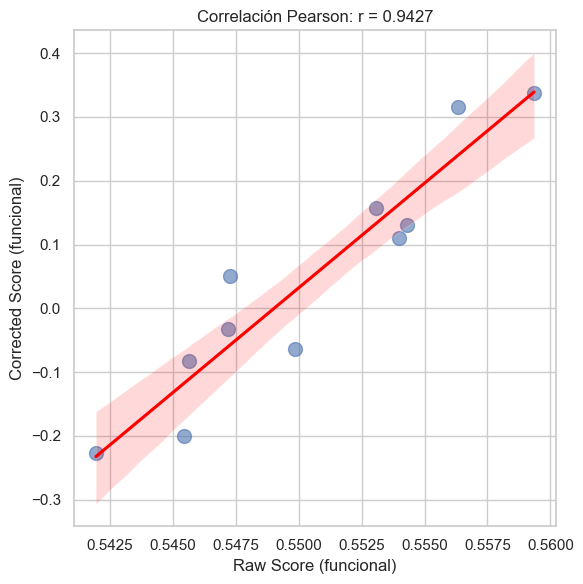

CONCLUSIÓN B: Una correlación de 0.9427 confirma que la corrección preserva la estructura relativa.


In [29]:
# B.2. Correlación de Pearson
# Calculamos qué tan parecidas son las curvas matemáticamente
corr, _ = pearsonr(df[col_raw], df[col_corr])

plt.figure(figsize=(6, 6))
sns.regplot(x=df[col_raw], y=df[col_corr], scatter_kws={'s':100, 'alpha':0.6}, line_kws={'color':'red'})
plt.title(f'Correlación Pearson: r = {corr:.4f}')
plt.xlabel(f'Raw Score ({axis})')
plt.ylabel(f'Corrected Score ({axis})')
plt.tight_layout()
plt.show()

print(f"CONCLUSIÓN B: Una correlación de {corr:.4f} confirma que la corrección preserva la estructura relativa.")

An almost perfect diagonal con $r \approx 0.94$. Existe una relación lineal fortísima entre los datos crudos y los corregidos.


📈 GENERATING BLOCK C: Layer Narrative Comparison...


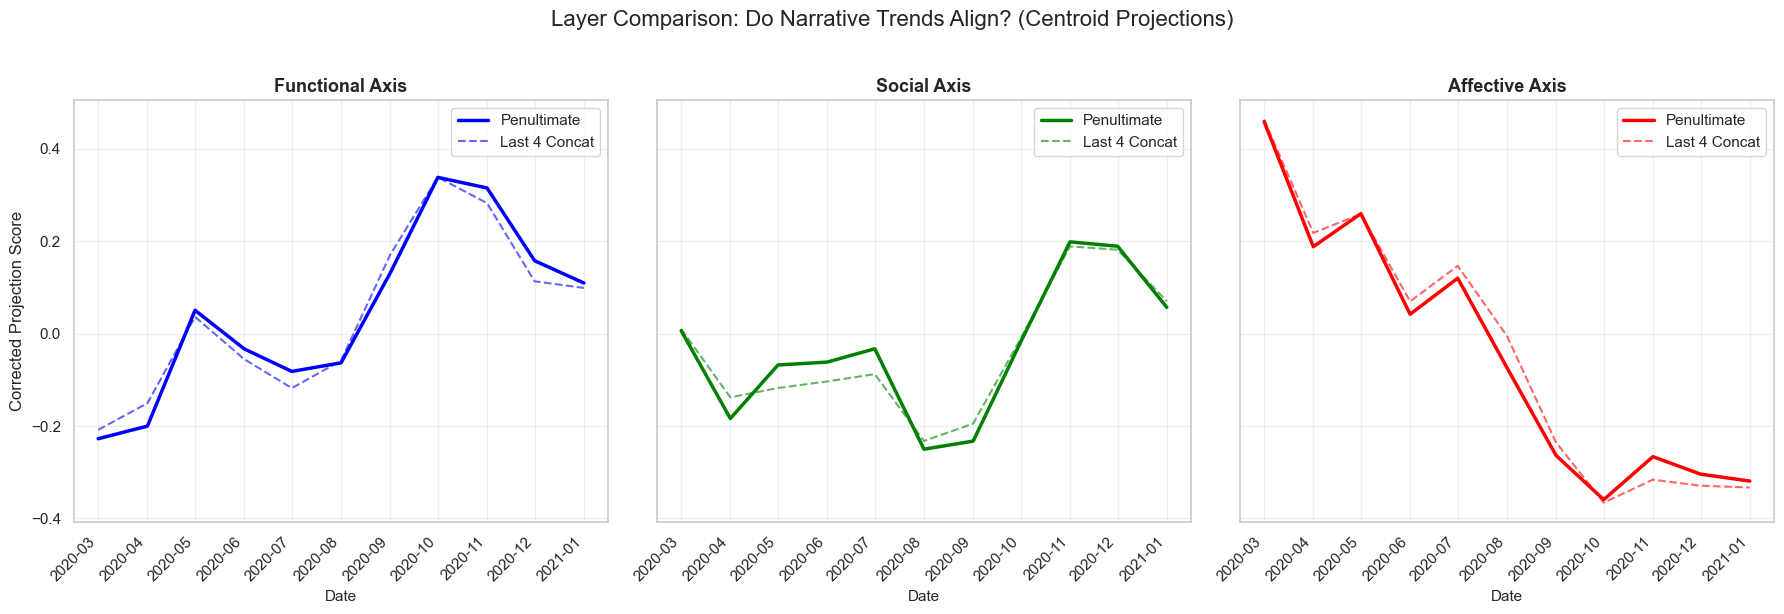

In [11]:
# ==============================================================================
# BLOCK C: AXIS ANALYSIS (THE NARRATIVE)
# Goal: Determine if the story (Functional/Social/Affective) changes by layer.
# ==============================================================================

print("\n📈 GENERATING BLOCK C: Layer Narrative Comparison...")

# Translation dictionary for the subplots
axis_titles = {
    'funcional': 'Functional Axis',
    'social': 'Social Axis',
    'afectiva': 'Affective Axis'
}

colors = {'funcional': 'blue', 'social': 'green', 'afectiva': 'red'}

# --- C.1 PENULTIMATE VS LAST4 (Do they tell the same story?) ---
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, ax_name in enumerate(['funcional', 'social', 'afectiva']):
    col_pen = f'centroid_proj_{ax_name}_dapt_penultimate_corrected'
    col_last4 = f'centroid_proj_{ax_name}_dapt_last4_concat_corrected'
    
    # Plot Penultimate (Solid)
    sns.lineplot(data=df, x='date', y=col_pen, ax=axs[i], 
                 color=colors[ax_name], linewidth=2.5, label='Penultimate')
    
    # Plot Last 4 Concat (Dashed)
    sns.lineplot(data=df, x='date', y=col_last4, ax=axs[i], 
                 color=colors[ax_name], linestyle='--', alpha=0.6, label='Last 4 Concat')
    
    # Set translated title
    axs[i].set_title(axis_titles[ax_name], fontsize=13, fontweight='bold')
    axs[i].set_xlabel('Date', fontsize=11)
    
    if i == 0: 
        axs[i].set_ylabel('Corrected Projection Score', fontsize=12)
    
    axs[i].grid(True, alpha=0.3)
    
    # --- Date Legibility Fix ---
    plt.setp(axs[i].get_xticklabels(), rotation=45, ha='right')
    
    axs[i].legend(loc='best', frameon=True)

plt.suptitle('Layer Comparison: Do Narrative Trends Align? (Centroid Projections)', y=1.02, fontsize=16)
plt.tight_layout()

# Save for thesis
# plt.savefig('Figure_8_Centroid_Layer_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()


📈 GENERATING BLOCK C.2: Subspace Narrative Comparison...


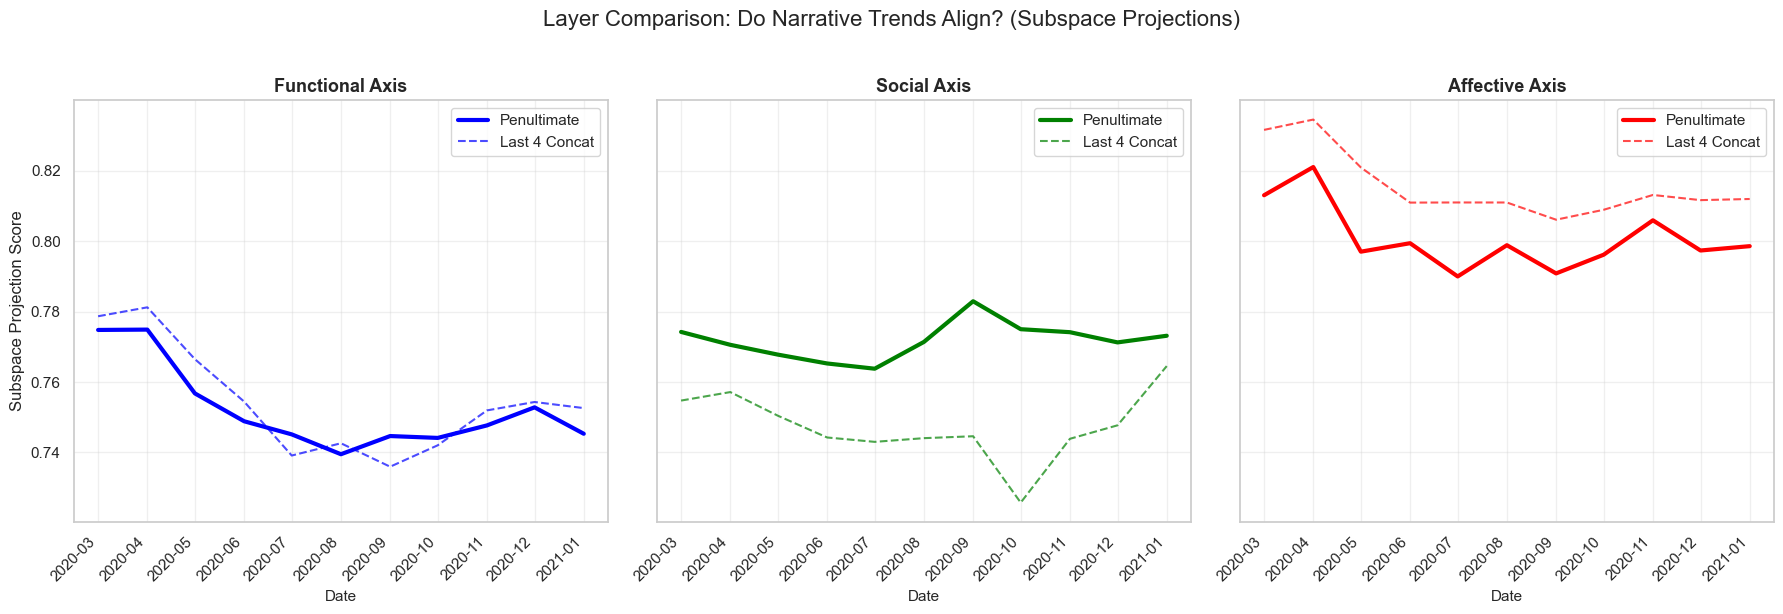

In [12]:
# ==============================================================================
# BLOCK C.2: SUBSPACE NARRATIVE COMPARISON (THE REVELATION)
# Goal: Show how subspaces expose the structural differences that centroids hide.
# ==============================================================================

print("\n📈 GENERATING BLOCK C.2: Subspace Narrative Comparison...")

# Translation dictionary
axis_titles = {
    'funcional': 'Functional Axis',
    'social': 'Social Axis',
    'afectiva': 'Affective Axis'
}
colors = {'funcional': 'blue', 'social': 'green', 'afectiva': 'red'}

fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, ax_name in enumerate(['funcional', 'social', 'afectiva']):
    # Note: We use 'subspace_proj' columns here
    col_pen = f'subspace_proj_{ax_name}_dapt_penultimate_corrected'
    col_last4 = f'subspace_proj_{ax_name}_dapt_last4_concat_corrected'
    
    # Plot Penultimate (Solid, Bold)
    sns.lineplot(data=df, x='date', y=col_pen, ax=axs[i], 
                 color=colors[ax_name], linewidth=3, label='Penultimate')
    
    # Plot Last 4 Concat (Dashed, Thinner)
    sns.lineplot(data=df, x='date', y=col_last4, ax=axs[i], 
                 color=colors[ax_name], linestyle='--', alpha=0.7, label='Last 4 Concat')
    
    # Titles and formatting
    axs[i].set_title(axis_titles[ax_name], fontsize=13, fontweight='bold')
    axs[i].set_xlabel('Date', fontsize=11)
    
    if i == 0: 
        axs[i].set_ylabel('Subspace Projection Score', fontsize=12)
    
    axs[i].grid(True, alpha=0.3)
    
    # --- Date Legibility (Rotation) ---
    plt.setp(axs[i].get_xticklabels(), rotation=45, ha='right')
    
    axs[i].legend(loc='best', frameon=True)

plt.suptitle('Layer Comparison: Do Narrative Trends Align? (Subspace Projections)', y=1.02, fontsize=16)
plt.tight_layout()

# Save for thesis
# plt.savefig('Figure_9_Subspace_Layer_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# 1. Eje Social
corr_centroid_social = df['centroid_proj_social_dapt_penultimate_corrected'].corr(df['centroid_proj_social_dapt_last4_concat_corrected'])
corr_subspace_social = df['subspace_proj_social_dapt_penultimate_corrected'].corr(df['subspace_proj_social_dapt_last4_concat_corrected'])

# 2. Eje Afectivo
corr_centroid_afectiva = df['centroid_proj_afectiva_dapt_penultimate_corrected'].corr(df['centroid_proj_afectiva_dapt_last4_concat_corrected'])
corr_subspace_afectiva = df['subspace_proj_afectiva_dapt_penultimate_corrected'].corr(df['subspace_proj_afectiva_dapt_last4_concat_corrected'])

# 3. Eje Functional
corr_centroid_funcional = df['centroid_proj_funcional_dapt_penultimate_corrected'].corr(df['centroid_proj_funcional_dapt_last4_concat_corrected'])
corr_subspace_funcional = df['subspace_proj_funcional_dapt_penultimate_corrected'].corr(df['subspace_proj_funcional_dapt_last4_concat_corrected'])

# Imprimir los resultados
print(f"Correlación Centroides (Social): {corr_centroid_social:.3f}")
print(f"Correlación Subespacios (Social): {corr_subspace_social:.3f}")
print("="*40)
print(f"Correlación Centroides (Affective): {corr_centroid_afectiva:.3f}")
print(f"Correlación Subespacios (Affective): {corr_subspace_afectiva:.3f}")
print("="*40)
print(f"Correlación Centroides (Functional): {corr_centroid_funcional:.3f}")
print(f"Correlación Subespacios (Functional): {corr_subspace_funcional:.3f}")

Correlación Centroides (Social): 0.975
Correlación Subespacios (Social): -0.068
Correlación Centroides (Afectiva): 0.995
Correlación Subespacios (Afectiva): 0.874
Correlación Centroides (Funcional): 0.987
Correlación Subespacios (Funcional): 0.940


Para los tres ejes (Functional, Social, Afectivo), la línea sólida y la punteada son casi idénticas (Correlación > 0.97 en todos los casos).

Dado que ambas cuentan la misma historia nos decantariamos por Penultimate, ya que tiene menos ruido y es más sencilla como hemos estado viendo en todo el analysis. 

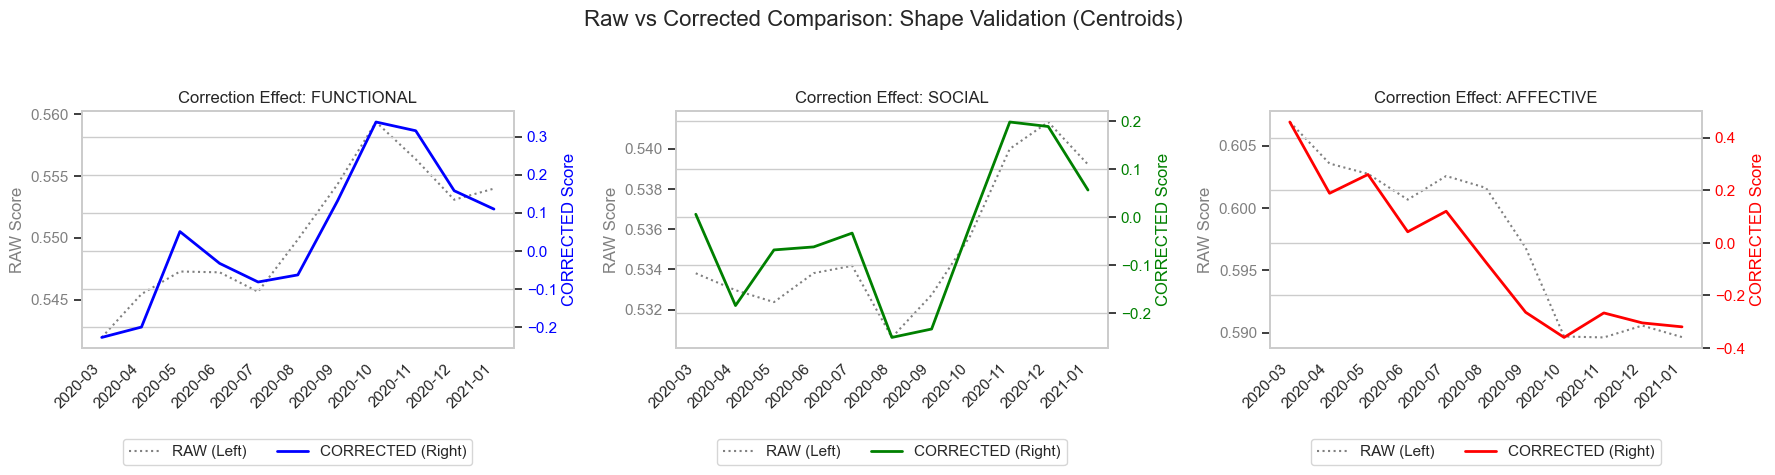

In [14]:
# --- C.2 RAW VS CORRECTED (Shape validation) ---
# Nos centramos en Penultimate y vemos el efecto de la corrección.
fig, axs = plt.subplots(1, 3, figsize=(18, 5)) # No sharey porque las escalas son distintas

# Diccionario para traducir los títulos sin romper los nombres de las columnas
axis_translation = {
    'funcional': 'Functional',
    'social': 'Social',
    'afectiva': 'Affective'
}

for i, ax_name in enumerate(axes_list):
    col_raw = f'centroid_proj_{ax_name}_dapt_penultimate_raw'
    col_corr = f'centroid_proj_{ax_name}_dapt_penultimate_corrected'
    
    # Left Axis (RAW)
    ax1 = axs[i]
    line1 = ax1.plot(df['date'], df[col_raw], color='gray', linestyle=':', label='RAW (Left)')
    ax1.set_ylabel('RAW Score', color='gray')
    ax1.tick_params(axis='y', labelcolor='gray')
    
    # Right Axis (CORRECTED)
    ax2 = ax1.twinx()
    line2 = ax2.plot(df['date'], df[col_corr], color=colors[ax_name], linewidth=2, label='CORRECTED (Right)')
    ax2.set_ylabel('CORRECTED Score', color=colors[ax_name])
    ax2.tick_params(axis='y', labelcolor=colors[ax_name])
    
    # Título traducido
    title_name = axis_translation.get(ax_name, ax_name).upper()
    ax1.set_title(f'Correction Effect: {title_name}')
    ax1.grid(False) # Grid solo en uno para no ensuciar
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

    # Leyenda combinada
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=2)

plt.suptitle('Raw vs Corrected Comparison: Shape Validation (Centroids)', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

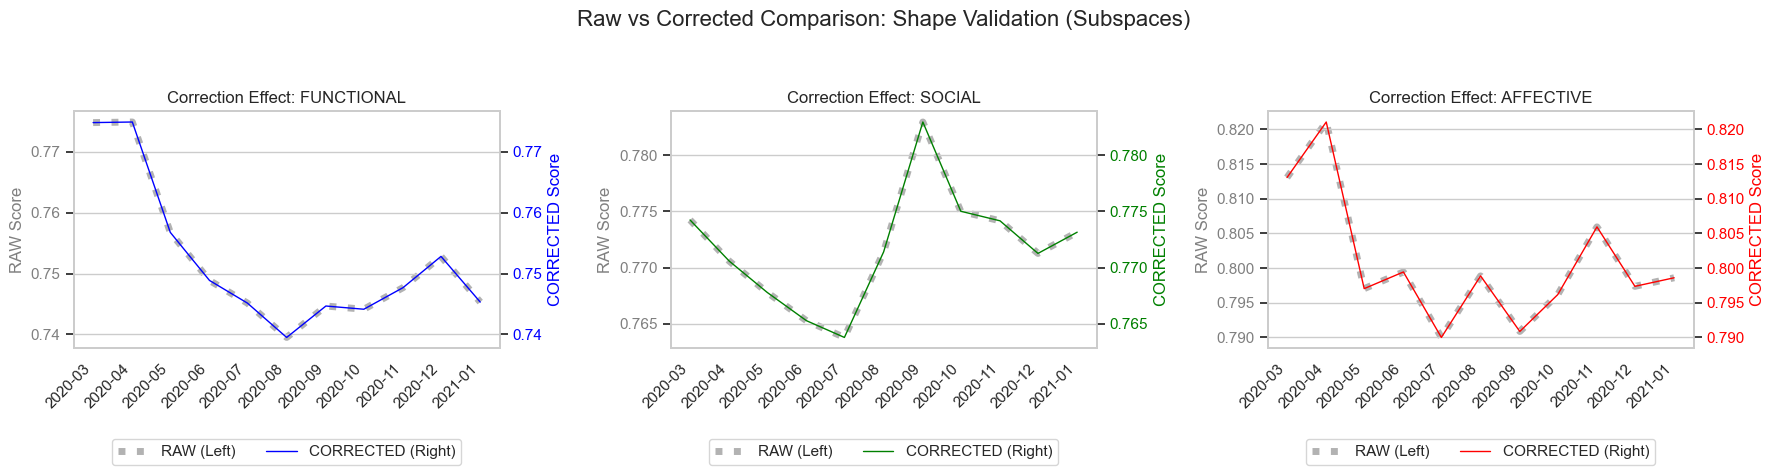

In [16]:
# --- C.2 RAW VS CORRECTED (Shape validation) ---
# Nos centramos en Penultimate y vemos el efecto de la corrección.
fig, axs = plt.subplots(1, 3, figsize=(18, 5)) # No sharey porque las escalas son distintas

# Diccionario para traducir los títulos sin romper los nombres de las columnas
axis_translation = {
    'funcional': 'Functional',
    'social': 'Social',
    'afectiva': 'Affective'
}

for i, ax_name in enumerate(axes_list):
    col_raw = f'subspace_proj_{ax_name}_dapt_penultimate_raw'
    col_corr = f'subspace_proj_{ax_name}_dapt_penultimate_corrected'
    
    # Left Axis (RAW)
    # Left Axis (RAW) - Hacemos la línea MUY gruesa para que asome por detrás
    ax1 = axs[i]
    line1 = ax1.plot(df['date'], df[col_raw], color='gray', linestyle=':', linewidth=5, alpha=0.6, label='RAW (Left)')
    ax1.set_ylabel('RAW Score', color='gray')
    ax1.tick_params(axis='y', labelcolor='gray')
    
    # Right Axis (CORRECTED)
    ax2 = ax1.twinx()
    line2 = ax2.plot(df['date'], df[col_corr], color=colors[ax_name], linewidth=1, label='CORRECTED (Right)')
    ax2.set_ylabel('CORRECTED Score', color=colors[ax_name])
    ax2.tick_params(axis='y', labelcolor=colors[ax_name])
    
    # Título traducido
    title_name = axis_translation.get(ax_name, ax_name).upper()
    ax1.set_title(f'Correction Effect: {title_name}')
    ax1.grid(False) # Grid solo en uno para no ensuciar
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

    # Leyenda combinada
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=2)

plt.suptitle('Raw vs Corrected Comparison: Shape Validation (Subspaces)', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
for ax_name in ['funcional', 'social', 'afectiva']:
    col_raw = f'subspace_proj_{ax_name}_dapt_penultimate_raw'
    col_corr = f'subspace_proj_{ax_name}_dapt_penultimate_corrected'
    
    # Calculate the absolute difference
    diff = (df[col_raw] - df[col_corr]).abs().mean()
    print(f"Mean Difference for {ax_name}: {diff:.10f}")

Mean Difference for funcional: 0.0000000000
Mean Difference for social: 0.0000000000
Mean Difference for afectiva: 0.0000000000


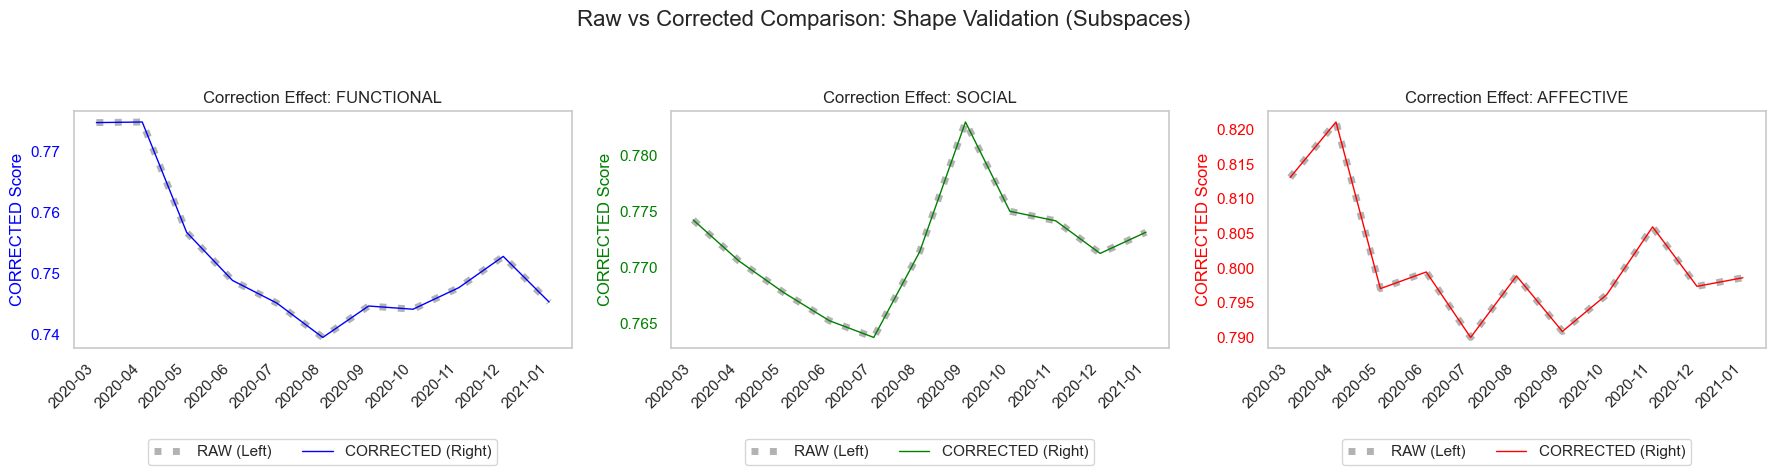

In [7]:
# --- C.2 RAW VS CORRECTED (Shape validation) ---
# Nos centramos en Penultimate y vemos el efecto de la corrección.
fig, axs = plt.subplots(1, 3, figsize=(18, 5)) # No sharey porque las escalas son distintas

# Diccionario para traducir los títulos sin romper los nombres de las columnas
axis_translation = {
    'funcional': 'Functional',
    'social': 'Social',
    'afectiva': 'Affective'
}

for i, ax_name in enumerate(axes_list):
    col_raw = f'subspace_proj_{ax_name}_dapt_penultimate_raw'
    col_corr = f'subspace_proj_{ax_name}_dapt_penultimate_corrected'
    
    # Left Axis (RAW)
    # Left Axis (RAW) - Hacemos la línea MUY gruesa para que asome por detrás
    ax1 = axs[i]
    line1 = ax1.plot(df['date'], df[col_raw], color='gray', linestyle=':', linewidth=5, alpha=0.6, label='RAW (Left)')
    ax1.set_ylabel('RAW Score', color='gray')
    ax1.tick_params(axis='y', labelcolor='gray')
    
    # Right Axis (CORRECTED)
    line2 = ax1.plot(df['date'], df[col_corr], color=colors[ax_name], linewidth=1, label='CORRECTED (Right)')
    ax1.set_ylabel('CORRECTED Score', color=colors[ax_name])
    ax1.tick_params(axis='y', labelcolor=colors[ax_name])
    
    # Título traducido
    title_name = axis_translation.get(ax_name, ax_name).upper()
    ax1.set_title(f'Correction Effect: {title_name}')
    ax1.grid(False) # Grid solo en uno para no ensuciar
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

    # Leyenda combinada
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=2)

plt.suptitle('Raw vs Corrected Comparison: Shape Validation (Subspaces)', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

Raw vs Corrected both present an almost identical morphology, siguiendo los mismos patrones. Ambas cuentan la misma historia. Si las curvas fueran muy distintas, significaría que la corrección está "rompiendo" los datos. Al ser iguales, significa que la corrección es segura y fiable.

La corrección de anisotropía actúa efectivamente como un re-escalado y centrado de la señal semántica, preservando intacta la estructura temporal y la narrativa evolutiva. Esto valida el uso de métricas corregidas para el reporte final, ya que ofrecen una interpretabilidad superior (centrada en el origen) sin sacrificar la fidelidad a los datos originales.


📈 GENERATING BLOCK D: Entropy Analysis...


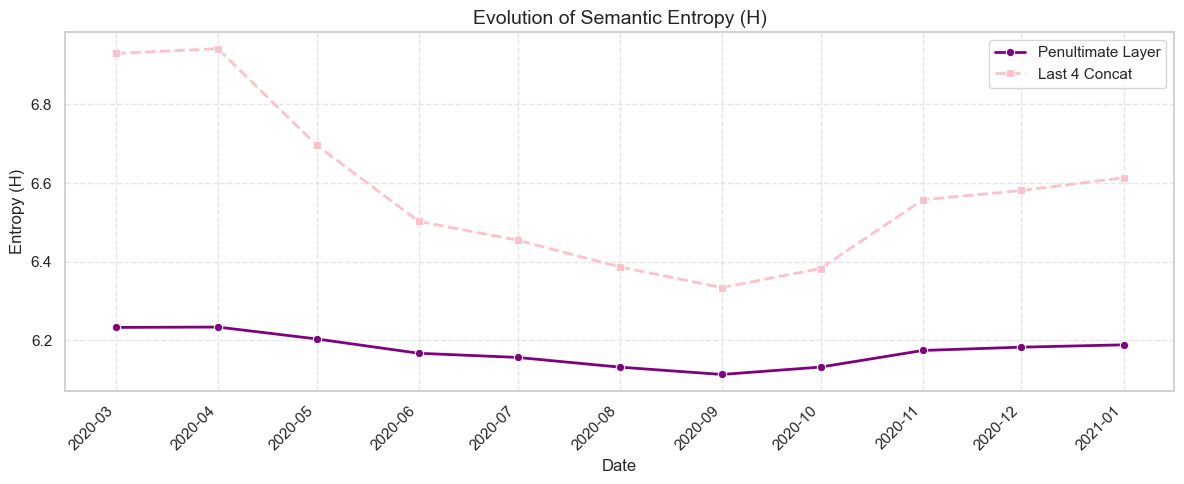

In [10]:
# ==============================================================================
# BLOCK D: SEMANTIC ENTROPY (AMBIGUITY)
# Goal: Measure how "dispersed" or "concentrated" the discourse is.
# ==============================================================================

print("\n📈 GENERATING BLOCK D: Entropy Analysis...")

plt.figure(figsize=(12, 5))

# 1. Plotting Penultimate Layer
sns.lineplot(data=df, x='date', y='entropy_dapt_penultimate', 
             label='Penultimate Layer', color='purple', linewidth=2, marker='o')

# 2. Plotting Last 4 Concat
sns.lineplot(data=df, x='date', y='entropy_dapt_last4_concat', 
             label='Last 4 Concat', color='pink', linestyle='--', linewidth=2, marker='s')

# --- English Translations and Styling ---
plt.title('Evolution of Semantic Entropy (H)', fontsize=14)
plt.ylabel('Entropy (H)', fontsize=12)
plt.xlabel('Date', fontsize=12)

# --- Date Legibility Fix ---
plt.xticks(rotation=45, ha='right')

plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Penultimate entropy is lower (6.17) que la de Last4 (6.58) y muestra una tendencia ligeramente descendente (pendiente negativa).

El discurso sobre salud mental se volvió menos ambiguo y más estandarizado con el tiempo. Last4 muestra más dispersión (más confusión).

De nuevo este plot solidifica y justifica nuestro razonamiento en cuanto a la decisión de elegir Penultimate.

## General Conclusion

Based on empirical evidence de los gráficos anteriores, establecemos las siguientes decisiones metodológicas para el análisis final:

1. Elección de Layer Strategy: PENULTIMATE LAYER. 
2. Corrected vs Raw: CORRECTED

Based on empirical evidence de los gráficos anteriores, establecemos las siguientes decisiones metodológicas para el análisis final:
1. Elección de Layer Strategy: PENULTIMATE LAYER

Decidimos extraer los embeddings de la penúltima capa del modelo DAPT basándonos en tres evidencias:
- Reducción de Ruido: Como demuestra el Plot A.1, la capa ``Last4Concat`` presenta una dimensionalidad intrínseca artificialmente alta ($k \approx 79$) debido a la retención de información sintáctica superficial. La capa ``Penultimate`` ($k \approx 48$) ofrece una abstracción semántica más eficiente.
- Estabilidad Temporal: El análisis de Drift (Plot A.2) revela que la capa final es inestable ante variaciones menores. La capa penúltima proporciona una trayectoria evolutiva más suave y coherente con procesos sociales graduales.
- Consistencia Narrativa: El Plot C.1 confirma que ambas estrategias narran la misma evolución histórica ($r > 0.97$ en todos los ejes). Por tanto, aplicamos el principio de parsimonia: elegimos la representación más simple y limpia (``Penultimate``) que no sacrifica información narrativa.

2. Elección de Technique: DUAL ANISOTROPY CORRECTION

Adoptamos la métrica corregida (Corrected) como estándar para nuestros reportes visuales:
- Robustez Validada: La alta correlación de Pearson ($r = 0.94$, Plot B.2) entre las señales ``Raw`` y ``Corrected`` demuestra que la corrección no introduce artefactos ni altera la tendencia temporal genuina de los datos.
- Rigor Geométrico: Aunque la tendencia es idéntica, la corrección elimina el sesgo anisotrópico inherente a los modelos Transformer (la tendencia de todos los vectores a agruparse en un cono estrecho), proporcionando distancias coseno geométricamente más precisas y centradas en el origen semántico real.

En resumen: Nuestro análisis se basará en **DAPT + Penultimate Layer + Corrected Metrics**, una combinación que garantiza la máxima pureza semántica, estabilidad temporal y rigor matemático.

---

C:\Users\alvar\AppData\Local\Temp\ipykernel_9012\340693180.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_9012\340693180.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_9012\340693180.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)


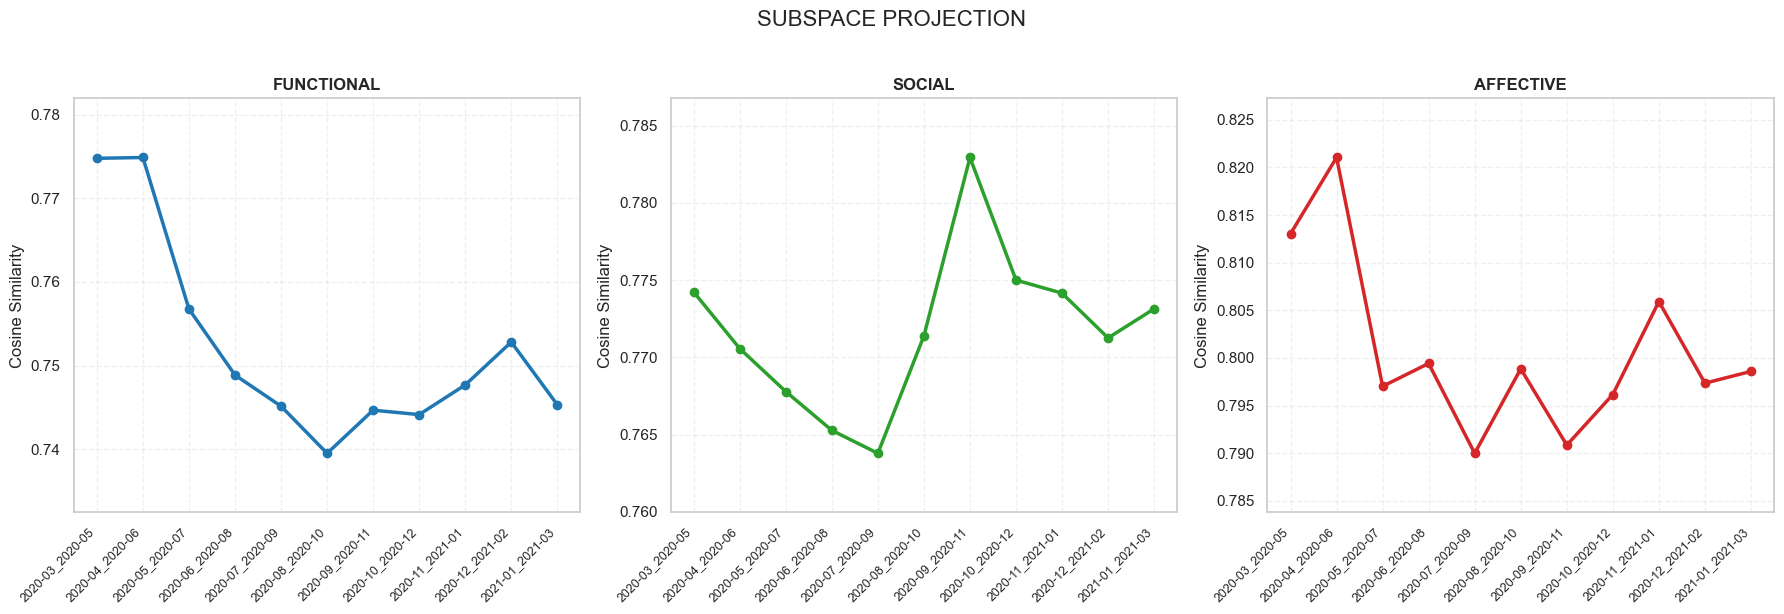

In [22]:
# --- Visual Configuration ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (18, 6)

# --- 2. RELATIVE IMPACT CALCULATION (Option B) ---
# We subtract the Baseline to eliminate the "0.8" base and see only the movement.
for axis in ['funcional', 'social', 'afectiva']:
    # Assuming these columns exist in your dataframe 'df'
    col_dapt = f'subspace_proj_{axis}_dapt_penultimate_corrected'
    col_base = f'subspace_proj_{axis}_baseline_penultimate_corrected'
    
    # Delta = Pandemic - Normalcy
    df[f'relative_impact_{axis}'] = df[col_dapt] - df[col_base]

# --- 3. PLOT WITH AUTOMATIC ZOOM ---
def plot_subspace_simple_zoom(df):
    # sharey=False allows for individual zoom on each subplot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) 
    
    dims = {
        'funcional': {'color': 'tab:blue', 'ax': axes[0], 'name_en': 'Functional'},
        'social':    {'color': 'tab:green', 'ax': axes[1], 'name_en': 'Social'},
        'afectiva':  {'color': 'tab:red', 'ax': axes[2], 'name_en': 'Affective'}
    }
    
    for dim_name, props in dims.items():
        ax = props['ax']
        color = props['color']
        english_name = props['name_en']
        
        # MASTER COLUMN (Corrected)
        col_dapt = f'subspace_proj_{dim_name}_dapt_penultimate_corrected'
        
        # Plotting the data
        ax.plot(df['window_label'], df[col_dapt], 
                color=color, marker='o', linewidth=2.5, label='Alignment (DAPT)')
        
        # Subplot Configuration
        ax.set_title(f"{english_name.upper()}", fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
        # Using "Cosine Similarity" for the y-axis label
        ax.set_ylabel("Cosine Similarity")
        
        # AUTO-ZOOM TRICK: We don't set a static set_ylim(0,1).
        # Instead, let matplotlib adjust based on the min/max values.
        # Then, add a small margin so data doesn't touch the plot edges.
        y_min, y_max = df[col_dapt].min(), df[col_dapt].max()
        margin = (y_max - y_min) * 0.2 # 20% margin
        ax.set_ylim(y_min - margin, y_max + margin)

    # Global Plot Title
    plt.suptitle("SUBSPACE PROJECTION", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Assuming 'df' is defined and populated with data, you would call the function like this:
plot_subspace_simple_zoom(df)

---

### Semantic Trajectory entre Functional y Social

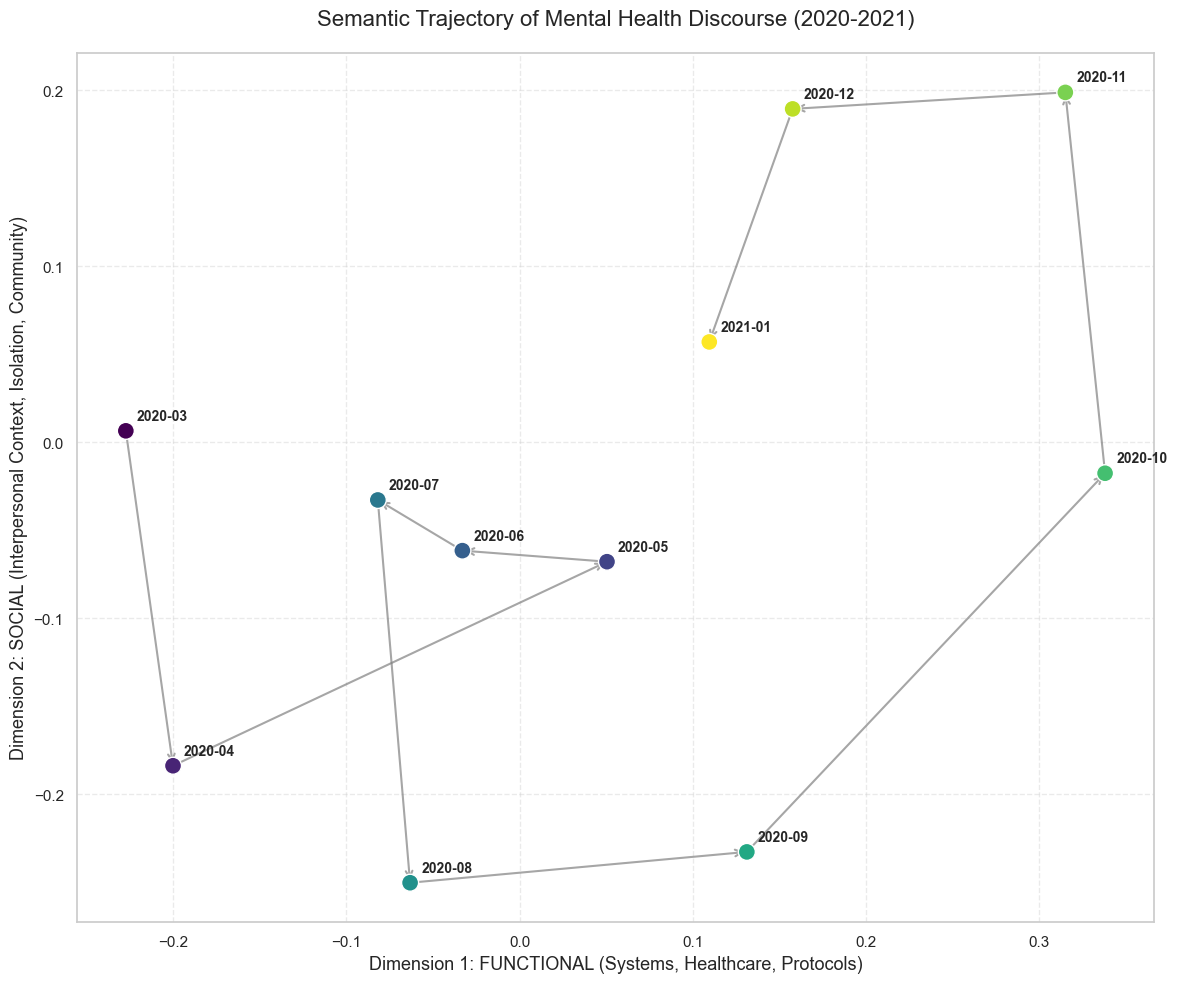

In [17]:
# ==============================================================================
# BLOCK G: SEMANTIC TRAJECTORY (Functional vs. Social Axis)
# Goal: Visualize the movement of the mental health concept through semantic space.
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Config
modelo = 'dapt_penultimate'
col_x = f'centroid_proj_funcional_{modelo}_corrected'
col_y = f'centroid_proj_social_{modelo}_corrected'

if col_x in df.columns and col_y in df.columns:
    plt.figure(figsize=(12, 10))
    
    # Data extraction
    x = df[col_x].values
    y = df[col_y].values
    dates = df['date'].dt.strftime('%Y-%m').values # Clean date format
    
    # Color gradient for time (Viridis: Purple=Start -> Yellow=End)
    colors = cm.viridis(np.linspace(0, 1, len(dates)))
    
    # Scatter points
    plt.scatter(x, y, c=colors, s=150, zorder=3, edgecolors='white', linewidth=1)
    
    # Connection arrows (The "Path")
    for i in range(len(dates)-1):
        plt.annotate('', xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                     arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7), 
                     zorder=2)
        
    # Date Labels
    for i, txt in enumerate(dates):
        plt.annotate(txt, (x[i], y[i]), xytext=(8, 8), 
                     textcoords='offset points', fontsize=10, fontweight='bold')
    
    # --- English Labels ---
    plt.title('Semantic Trajectory of Mental Health Discourse (2020-2021)', fontsize=16, pad=20)
    plt.xlabel('Dimension 1: FUNCTIONAL (Systems, Healthcare, Protocols)', fontsize=13)
    plt.ylabel('Dimension 2: SOCIAL (Interpersonal Context, Isolation, Community)', fontsize=13)
    
    # Aesthetics
    plt.grid(True, linestyle='--', alpha=0.4, zorder=1)
    
    plt.tight_layout()
    # plt.savefig('Figure_14_Semantic_Trajectory.png', dpi=300)
    plt.show()
else:
    print("Error: Columns not found.")

### Semantic Trajectory entre Functional y Affective

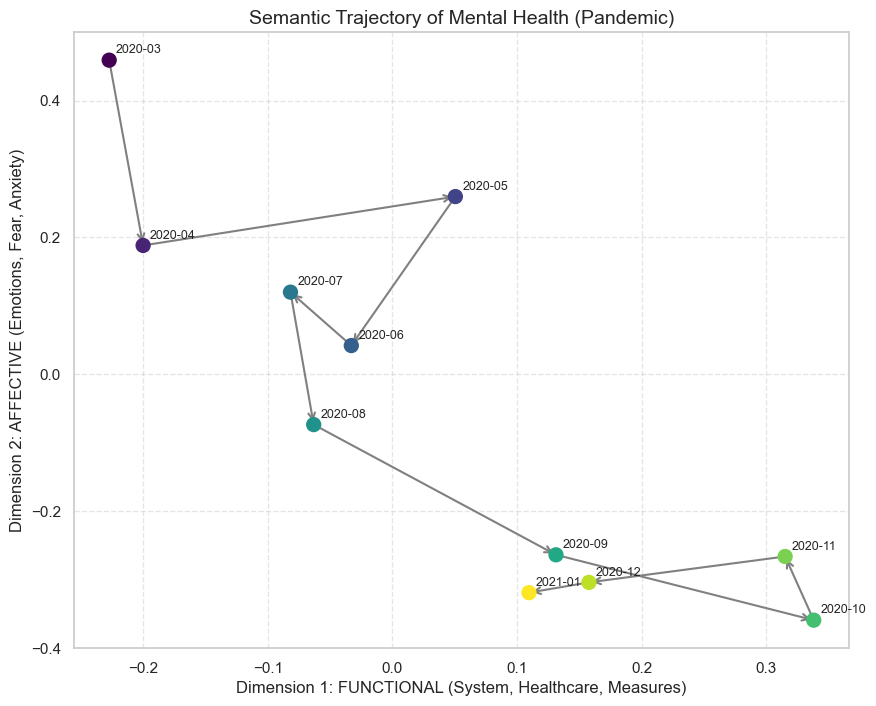

Interpretation: Follow the direction of the arrows. If they move toward the upper-right, it suggests the discourse became less emotional and more focused on healthcare pragmatism.


In [19]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Define the model we are using
modelo = 'dapt_penultimate'

# Define Axis 1 and Axis 2
# X Axis: Evolution toward Functional (System, healthcare, treatments)
col_x = f'centroid_proj_funcional_{modelo}_corrected'
# Y Axis: Evolution toward Affective (Emotions, fear, sadness)
col_y = f'centroid_proj_afectiva_{modelo}_corrected'

if col_x in df.columns and col_y in df.columns:
    plt.figure(figsize=(10, 8))
    
    # Extract data
    x = df[col_x].values
    y = df[col_y].values
    fechas = df['window_start_month'].values
    
    # Create a color gradient to represent time (light → dark)
    colors = cm.viridis(np.linspace(0, 1, len(fechas)))
    
    # Plot points
    plt.scatter(x, y, c=colors, s=100, zorder=3)
    
    # Connect points with arrows to show time direction
    for i in range(len(fechas)-1):
        plt.annotate('', xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                     arrowprops=dict(arrowstyle="->", color="gray", lw=1.5), zorder=2)
        
    # Add date labels to each point
    for i, txt in enumerate(fechas):
        plt.annotate(txt, (x[i], y[i]), xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    # Aesthetic settings
    plt.title('Semantic Trajectory of Mental Health (Pandemic)', fontsize=14)
    plt.xlabel('Dimension 1: FUNCTIONAL (System, Healthcare, Measures)', fontsize=12)
    plt.ylabel('Dimension 2: AFFECTIVE (Emotions, Fear, Anxiety)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5, zorder=1)
    
    plt.show()
    
    print("Interpretation: Follow the direction of the arrows. If they move toward the upper-right, it suggests the discourse became less emotional and more focused on healthcare pragmatism.")
else:
    print(f"Error: Columns {col_x} or {col_y} not found")

### Semantic Trajectory Social y Affective

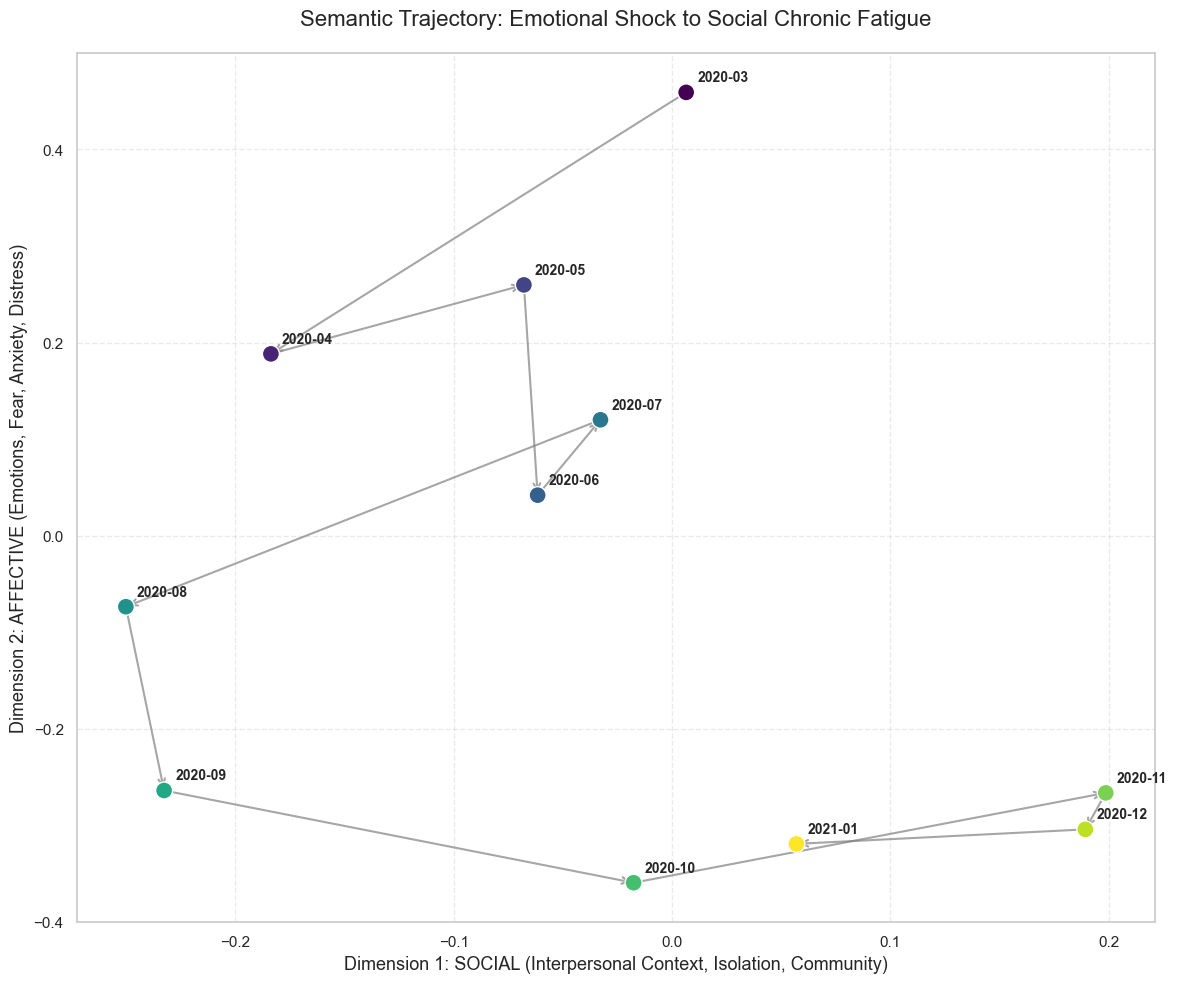

In [16]:
# ==============================================================================
# BLOCK H: SEMANTIC TRAJECTORY (Social vs. Affective Axis)
# Goal: Visualize the shift from emotional crisis to social restructuring.
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Config
modelo = 'dapt_penultimate'
col_x = f'centroid_proj_social_{modelo}_corrected'
col_y = f'centroid_proj_afectiva_{modelo}_corrected'

if col_x in df.columns and col_y in df.columns:
    plt.figure(figsize=(12, 10))
    
    # Data extraction
    x = df[col_x].values
    y = df[col_y].values
    dates = df['date'].dt.strftime('%Y-%m').values
    
    # Color gradient (Viridis: Purple=Early, Yellow=Late)
    colors = cm.viridis(np.linspace(0, 1, len(dates)))
    
    # Scatter points with white edges for clarity
    plt.scatter(x, y, c=colors, s=150, zorder=3, edgecolors='white', linewidth=1)
    
    # Connection arrows
    for i in range(len(dates)-1):
        plt.annotate('', xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                     arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7), 
                     zorder=2)
        
    # Bold Date Labels
    for i, txt in enumerate(dates):
        plt.annotate(txt, (x[i], y[i]), xytext=(8, 8), 
                     textcoords='offset points', fontsize=10, fontweight='bold')
    
    # --- English Labels ---
    plt.title('Semantic Trajectory: Emotional Shock to Social Chronic Fatigue', fontsize=16, pad=20)
    plt.xlabel('Dimension 1: SOCIAL (Interpersonal Context, Isolation, Community)', fontsize=13)
    plt.ylabel('Dimension 2: AFFECTIVE (Emotions, Fear, Anxiety, Distress)', fontsize=13)
    
    # Aesthetics
    plt.grid(True, linestyle='--', alpha=0.4, zorder=1)
    
    plt.tight_layout()
    # plt.savefig('Figure_15_Social_vs_Affective_Trajectory.png', dpi=300)
    plt.show()
else:
    print("Error: Columns not found.")